In [1]:
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime as dt
import re, math, textwrap
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.lines import Line2D
import seaborn as sns
import re
import warnings
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.multicomp import pairwise_tukeyhsd
warnings.filterwarnings("ignore")

# Optional: nice dataframe display in notebooks (falls back to print)
try:
    from IPython.display import display  # type: ignore
    def display_df(title, x):
        print(title)
        display(x)
except Exception:
    def display_df(title, x):
        print(title)
        print(x)


# Set the input path ONCE (edit this one line only)
CSV_PATH = Path('/Users/loukia/Library/CloudStorage/Dropbox-UCL/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/csv_files/concatenated_phase_precession.csv')
phase_precession_DIR = CSV_PATH.parent
phase_precession_OUTDIR = CSV_PATH.parent.parent / "Analysis" / "Phase_Precession_analysis"

phase_precession_OUTDIR.mkdir(parents=True, exist_ok=True)
print("Saving outputs to:", phase_precession_OUTDIR)\

df_phase_precession = pd.read_csv(CSV_PATH) #select all cells in all trials


# check if parket file exists and is up to date, otherwise save to parquet for faster loading next time
PARQUET_PATH = os.path.join(phase_precession_OUTDIR, "phase_precession.parquet")
df_phase_precession.to_parquet(PARQUET_PATH, index=False)
df_phase_precession = pd.read_parquet(PARQUET_PATH)
print(df_phase_precession.head())

Saving outputs to: /Users/loukia/Library/CloudStorage/Dropbox-UCL/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/Analysis/Phase_Precession_analysis
                                            filename  channel  cluster  \
0  /home/robin/Documents/Science/SWC/jok_loukia_r...        5        2   
1  /home/robin/Documents/Science/SWC/jok_loukia_r...        4        3   
2  /home/robin/Documents/Science/SWC/jok_loukia_r...        1        4   
3  /home/robin/Documents/Science/SWC/jok_loukia_r...        5        4   
4  /home/robin/Documents/Science/SWC/jok_loukia_r...        1        7   

     Cell type Genotype         mouse_name run_direction  n_spikes     slope  \
0  Interneuron     NLGF  concatenated_data             e        70 -0.220723   
1  Interneuron     NLGF  concatenated_data             e       108  4.797076   
2  Interneuron     NLGF  concatenated_data             w         7 -2.195272   
3  Interneuron     NLGF  concatenated_data             e        40 -2.

In [2]:
df_negative_sig = df_phase_precession[
    (df_phase_precession["rho"] < 0) & (df_phase_precession["pval"] < 0.05) & (df_phase_precession["n_spikes"] > 5)
]

counts_by_genotype = (
    df_negative_sig.groupby(["Genotype", "Cell type"])
    .size()
    .unstack(fill_value=0)
)

print(f"Number of cells with rho < 0 and pval < 0.05: {len(df_negative_sig)}")
display_df("Counts of Pyramidal and Interneuron cells for each Genotype:", counts_by_genotype)

Number of cells with rho < 0 and pval < 0.05: 43
Counts of Pyramidal and Interneuron cells for each Genotype:


Cell type,Interneuron,Pyramidal
Genotype,,
NLGF,0,5
WT,4,34


### This cell analyses genotype differences in `rho` within `df_negative_sig` (cells with rho < 0 and pval < 0.05).

Specifically, it:
1) Tests normality of rho per genotype (Shapiro-Wilk).
2) Chooses the group comparison test:    - Tukey HSD if normality holds   - Pairwise Mann-Whitney U if normality is violated
3) Visualizes mean rho by genotype with:
   - barplot (mean ± CI/SEM-like error bars)
   - individual data points (stripplot)
 4) Annotates pairwise significance on the plot (U and p values).
 5) Saves the figure to `phase_precession_OUTDIR / "mean_rho_barplot.pdf"`.


In short: it tests and plots whether phase precession strength (rho) differs by genotype.

In [3]:
# Check normality per Genotype using Shapiro-Wilk test
from scipy.stats import shapiro, mannwhitneyu
from itertools import combinations

genotypes = df_negative_sig["Genotype"].unique()
normality_passed = True
for g in genotypes:
    stat, p = shapiro(df_negative_sig.loc[df_negative_sig["Genotype"] == g, "rho"])
    print(f"Shapiro-Wilk test for {g}: W={stat:.4f}, p={p:.4f}")
    if p < 0.05:
        normality_passed = False

# Collect pairwise results
genotype_order = ["WT"] + [g for g in sorted(genotypes) if g != "WT"]
pairwise_results = []
if normality_passed:
    print("\nNormality assumption holds — running Tukey's HSD test:")
    tukey = pairwise_tukeyhsd(endog=df_negative_sig["rho"], groups=df_negative_sig["Genotype"], alpha=0.05)
    print(tukey.summary())
else:
    print("\nNormality assumption violated — running pairwise Mann-Whitney U tests:")
    for g1, g2 in combinations(genotype_order, 2):
        x = df_negative_sig.loc[df_negative_sig["Genotype"] == g1, "rho"]
        y = df_negative_sig.loc[df_negative_sig["Genotype"] == g2, "rho"]
        stat, p = mannwhitneyu(x, y, alternative="two-sided")
        pairwise_results.append((g1, g2, stat, p))
        print(f"  {g1} vs {g2}: U={stat:.1f}, p={p:.4f}")

Shapiro-Wilk test for NLGF: W=0.9555, p=0.7761
Shapiro-Wilk test for WT: W=0.7298, p=0.0000

Normality assumption violated — running pairwise Mann-Whitney U tests:
  WT vs NLGF: U=57.0, p=0.1601


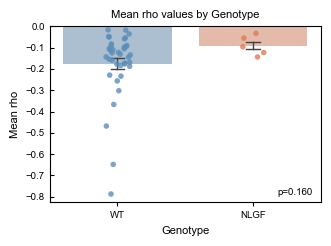

In [4]:
# Plotting the mean rho values for each Genotype with SEM and individual data points
import matplotlib as mpl

mpl.rcParams.update({
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "font.family": "Arial",
    "axes.grid": False,
    "font.size": 8,
    "axes.labelsize": 8,
    "axes.titlesize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 7,
    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "ytick.left": True,
    "ytick.direction": "in",
    "savefig.transparent": True,
    "savefig.bbox": "tight",
})

GENO_ORDER  = ["WT", "NLGF"]                          # WT first
GENO_COLORS = {"NLGF": "#E07B54", "WT": "#5B8DB8"}   # orange / steel-blue

# Plotting the mean rho values for each Genotype with SEM and individual data points
fig, ax = plt.subplots(figsize=(3.35, 2.5))
sns.barplot(x="Genotype", y="rho", data=df_negative_sig, ci=68,
            estimator=np.mean, capsize=0.1, errwidth=1, order=GENO_ORDER, 
            palette=GENO_COLORS, ax=ax, alpha=0.55)
sns.stripplot(x="Genotype", y="rho", data=df_negative_sig, palette=GENO_COLORS,
              alpha=0.8, jitter=True, size=4, order=GENO_ORDER, ax=ax)

# Add significance brackets
# Add p-value annotation (bottom right)
if pairwise_results:
    for g1, g2, stat, pval in pairwise_results:
        if not normality_passed:
            label = "p<0.001" if pval < 0.001 else f"p={pval:.3f}"
        else:
            label = "p-adj<0.001" if pval < 0.001 else f"p-adj={pval:.3f}"
        ax.text(0.97, 0.03, label, transform=ax.transAxes,
                ha="right", va="bottom", fontsize=7)

ax.set_title("Mean rho values by Genotype")
ax.set_xlabel("Genotype")
ax.set_ylabel("Mean rho")
plt.tight_layout()
plt.savefig(phase_precession_OUTDIR / "mean_rho_barplot.pdf")
plt.show()

In [5]:
# Chi-square test: proportion of phase-precessing cells (rho<0 & pval<0.05) by Genotype
df_phase_precession["phase_precessing"] = (
    (df_phase_precession["rho"] < 0) & (df_phase_precession["pval"] < 0.05) & (df_phase_precession["n_spikes"] > 5)
)

contingency = pd.crosstab(df_phase_precession["Genotype"], df_phase_precession["phase_precessing"],
                           margins=False)
contingency.columns = ["Non-precessing", "Precessing"]
genotype_order = ["WT"] + [g for g in contingency.index if g != "WT"]
contingency = contingency.loc[genotype_order]
display_df("Contingency table:", contingency)
save_csv_path = phase_precession_OUTDIR / "phase_precession_contingency.csv"
contingency.to_csv(save_csv_path)
print(f"Contingency table saved to: {save_csv_path}")

from scipy.stats import chi2_contingency
chi2, p, dof, expected = chi2_contingency(contingency)
print(f"\nChi-square test: chi2={chi2:.4f}, p-value={p:.4f}, dof={dof}")
print(f"Expected counts:\n{pd.DataFrame(expected, index=contingency.index, columns=contingency.columns).round(1)}")

# Show proportions
proportions = contingency.div(contingency.sum(axis=1), axis=0)
display_df("\nProportion of precessing cells per Genotype:", proportions)
save_csv_path = phase_precession_OUTDIR / "phase_precession_proportions.csv"
proportions.to_csv(save_csv_path)
print(f"Proportions saved to: {save_csv_path}")

Contingency table:


,Non-precessing,Precessing
Genotype,,
WT,185,38
NLGF,102,5


Contingency table saved to: /Users/loukia/Library/CloudStorage/Dropbox-UCL/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/Analysis/Phase_Precession_analysis/phase_precession_contingency.csv

Chi-square test: chi2=8.6984, p-value=0.0032, dof=1
Expected counts:
          Non-precessing  Precessing
Genotype                            
WT                 193.9        29.1
NLGF                93.1        13.9

Proportion of precessing cells per Genotype:


,Non-precessing,Precessing
Genotype,,
WT,0.829596,0.170404
NLGF,0.953271,0.046729


Proportions saved to: /Users/loukia/Library/CloudStorage/Dropbox-UCL/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/Analysis/Phase_Precession_analysis/phase_precession_proportions.csv


# Pyramidal only - not necessary 

Shapiro-Wilk test for NLGF: W=0.9555, p=0.7761
Shapiro-Wilk test for WT: W=0.7409, p=0.0000

Normality assumption violated — running pairwise Mann-Whitney U tests:
  WT vs NLGF: U=51.0, p=0.1643


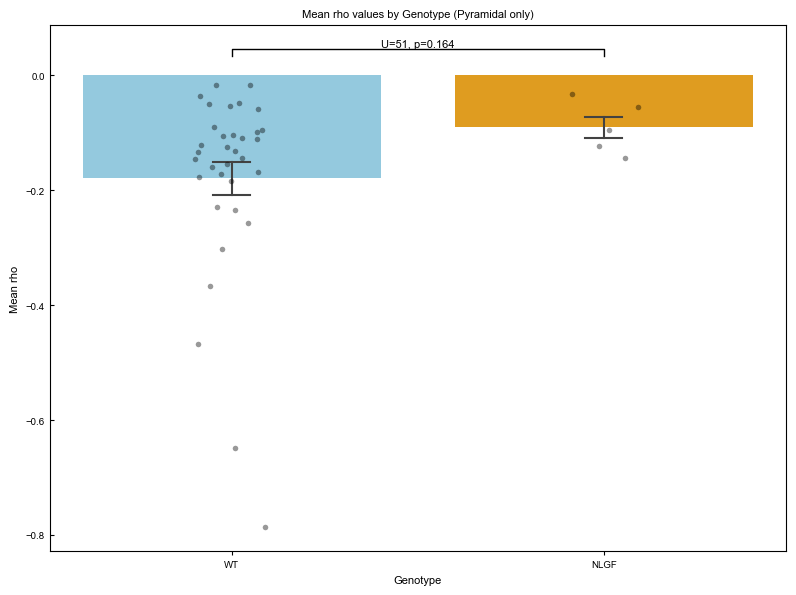

In [6]:
# Check normality per Genotype using Shapiro-Wilk test (Pyramidal only)
from scipy.stats import shapiro, mannwhitneyu
from itertools import combinations

df_negative_sig_pyr = df_negative_sig[df_negative_sig["Cell type"] == "Pyramidal"]

genotypes = df_negative_sig_pyr["Genotype"].unique()
normality_passed = True
for g in genotypes:
    stat, p = shapiro(df_negative_sig_pyr.loc[df_negative_sig_pyr["Genotype"] == g, "rho"])
    print(f"Shapiro-Wilk test for {g}: W={stat:.4f}, p={p:.4f}")
    if p < 0.05:
        normality_passed = False

# Collect pairwise results
genotype_order = ["WT"] + [g for g in sorted(genotypes) if g != "WT"]
pairwise_results = []
if normality_passed:
    print("\nNormality assumption holds — running Tukey's HSD test:")
    tukey = pairwise_tukeyhsd(endog=df_negative_sig_pyr["rho"], groups=df_negative_sig_pyr["Genotype"], alpha=0.05)
    print(tukey.summary())
else:
    print("\nNormality assumption violated — running pairwise Mann-Whitney U tests:")
    for g1, g2 in combinations(genotype_order, 2):
        x = df_negative_sig_pyr.loc[df_negative_sig_pyr["Genotype"] == g1, "rho"]
        y = df_negative_sig_pyr.loc[df_negative_sig_pyr["Genotype"] == g2, "rho"]
        stat, p = mannwhitneyu(x, y, alternative="two-sided")
        pairwise_results.append((g1, g2, stat, p))
        print(f"  {g1} vs {g2}: U={stat:.1f}, p={p:.4f}")

# Plotting the mean rho values for each Genotype with SEM and individual data points (Pyramidal only)
fig, ax = plt.subplots(figsize=(8, 6))
palette = {g: "orange" if g == "NLGF" else "skyblue" for g in genotype_order}
sns.barplot(x="Genotype", y="rho", data=df_negative_sig_pyr, ci=68,
            estimator=np.mean, capsize=0.1, errwidth=1.5, order=genotype_order, 
            palette=palette, ax=ax)
sns.stripplot(x="Genotype", y="rho", data=df_negative_sig_pyr, color="black", alpha=0.4, 
              jitter=True, size=4, order=genotype_order, ax=ax)

# Add significance brackets
if pairwise_results:
    y_max = df_negative_sig_pyr["rho"].max()
    y_range = df_negative_sig_pyr["rho"].max() - df_negative_sig_pyr["rho"].min()
    step = y_range * 0.08
    idx_map = {g: i for i, g in enumerate(genotype_order)}
    for k, (g1, g2, stat, pval) in enumerate(pairwise_results):
        x1, x2 = idx_map[g1], idx_map[g2]
        y = y_max + step * (k + 1)
        if pval < 0.001:
            label = f"U={stat:.0f}, p<0.001"
        else:
            label = f"U={stat:.0f}, p={pval:.3f}"
        ax.plot([x1, x1, x2, x2], [y - step * 0.2, y, y, y - step * 0.2], color="black", lw=1)
        ax.text((x1 + x2) / 2, y, label, ha="center", va="bottom", fontsize=8)

ax.set_title("Mean rho values by Genotype (Pyramidal only)")
ax.set_xlabel("Genotype")
ax.set_ylabel("Mean rho")
plt.tight_layout()
plt.savefig(phase_precession_OUTDIR / "mean_rho_barplot_pyramidal.pdf")
plt.show()

In [7]:
# Chi-square test: proportion of phase-precessing PYRAMIDAL cells by Genotype
df_pyramidal = df_phase_precession[df_phase_precession["Cell type"] == "Pyramidal"].copy()
df_pyramidal["phase_precessing"] = (
    (df_pyramidal["rho"] < 0) & (df_pyramidal["pval"] < 0.05)
)

contingency_pyr = pd.crosstab(df_pyramidal["Genotype"], df_pyramidal["phase_precessing"], margins=False)
contingency_pyr.columns = ["Non-precessing", "Precessing"]
genotype_order = ["WT"] + [g for g in contingency_pyr.index if g != "WT"]
contingency_pyr = contingency_pyr.loc[genotype_order]
display_df("Contingency table (Pyramidal only):", contingency_pyr)
save_csv_path = phase_precession_OUTDIR / "phase_precession_contingency_pyramidal.csv"
contingency_pyr.to_csv(save_csv_path)
print(f"Contingency table saved to: {save_csv_path}")

chi2, p, dof, expected = chi2_contingency(contingency_pyr)
print(f"\nChi-square test (Pyramidal only): chi2={chi2:.4f}, p-value={p:.4f}, dof={dof}")
print(f"Expected counts:\n{pd.DataFrame(expected, index=contingency_pyr.index, columns=contingency_pyr.columns).round(1)}")

proportions_pyr = contingency_pyr.div(contingency_pyr.sum(axis=1), axis=0)
display_df("\nProportion of precessing Pyramidal cells per Genotype:", proportions_pyr)
save_csv_path = phase_precession_OUTDIR / "phase_precession_proportions_pyramidal.csv"
proportions_pyr.to_csv(save_csv_path)
print(f"Proportions saved to: {save_csv_path}")

Contingency table (Pyramidal only):


,Non-precessing,Precessing
Genotype,,
WT,170,37
NLGF,83,7


Contingency table saved to: /Users/loukia/Library/CloudStorage/Dropbox-UCL/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/Analysis/Phase_Precession_analysis/phase_precession_contingency_pyramidal.csv

Chi-square test (Pyramidal only): chi2=4.2985, p-value=0.0381, dof=1
Expected counts:
          Non-precessing  Precessing
Genotype                            
WT                 176.3        30.7
NLGF                76.7        13.3

Proportion of precessing Pyramidal cells per Genotype:


,Non-precessing,Precessing
Genotype,,
WT,0.821256,0.178744
NLGF,0.922222,0.077778


Proportions saved to: /Users/loukia/Library/CloudStorage/Dropbox-UCL/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/Analysis/Phase_Precession_analysis/phase_precession_proportions_pyramidal.csv


In [8]:
# Chi-square test: proportion of phase-precessing PYRAMIDAL cells by Genotype
df_pyramidal = df_phase_precession[df_phase_precession["Cell type"] == "Pyramidal"].copy()
df_pyramidal["phase_precessing"] = (
    (df_pyramidal["rho"] < 0) & (df_pyramidal["pval"] < 0.05)
)

contingency_pyr = pd.crosstab(df_pyramidal["Genotype"], df_pyramidal["phase_precessing"], margins=False)
contingency_pyr.columns = ["Non-precessing", "Precessing"]
genotype_order = ["WT"] + [g for g in contingency_pyr.index if g != "WT"]
contingency_pyr = contingency_pyr.loc[genotype_order]
display_df("Contingency table (Pyramidal only):", contingency_pyr)
save_csv_path = phase_precession_OUTDIR / "phase_precession_contingency_pyramidal.csv"
contingency_pyr.to_csv(save_csv_path)
print(f"Contingency table saved to: {save_csv_path}")

chi2, p, dof, expected = chi2_contingency(contingency_pyr)
print(f"\nChi-square test (Pyramidal only): chi2={chi2:.4f}, p-value={p:.4f}, dof={dof}")
print(f"Expected counts:\n{pd.DataFrame(expected, index=contingency_pyr.index, columns=contingency_pyr.columns).round(1)}")

proportions_pyr = contingency_pyr.div(contingency_pyr.sum(axis=1), axis=0)
display_df("\nProportion of precessing Pyramidal cells per Genotype:", proportions_pyr)
save_csv_path = phase_precession_OUTDIR / "phase_precession_proportions_pyramidal.csv"
proportions_pyr.to_csv(save_csv_path)
print(f"Proportions saved to: {save_csv_path}")

Contingency table (Pyramidal only):


,Non-precessing,Precessing
Genotype,,
WT,170,37
NLGF,83,7


Contingency table saved to: /Users/loukia/Library/CloudStorage/Dropbox-UCL/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/Analysis/Phase_Precession_analysis/phase_precession_contingency_pyramidal.csv

Chi-square test (Pyramidal only): chi2=4.2985, p-value=0.0381, dof=1
Expected counts:
          Non-precessing  Precessing
Genotype                            
WT                 176.3        30.7
NLGF                76.7        13.3

Proportion of precessing Pyramidal cells per Genotype:


,Non-precessing,Precessing
Genotype,,
WT,0.821256,0.178744
NLGF,0.922222,0.077778


Proportions saved to: /Users/loukia/Library/CloudStorage/Dropbox-UCL/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/Analysis/Phase_Precession_analysis/phase_precession_proportions_pyramidal.csv


Saved plot to: /Users/loukia/Library/CloudStorage/Dropbox-UCL/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/Analysis/Phase_Precession_analysis/phase_precession_proportions_stacked.pdf
Saved plot to: /Users/loukia/Library/CloudStorage/Dropbox-UCL/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/Analysis/Phase_Precession_analysis/phase_precession_proportions_stacked.png


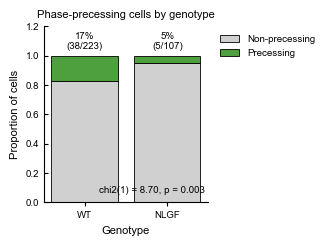

Saved plot to: /Users/loukia/Library/CloudStorage/Dropbox-UCL/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/Analysis/Phase_Precession_analysis/phase_precession_proportions_pyramidal_stacked.pdf
Saved plot to: /Users/loukia/Library/CloudStorage/Dropbox-UCL/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/Analysis/Phase_Precession_analysis/phase_precession_proportions_pyramidal_stacked.png


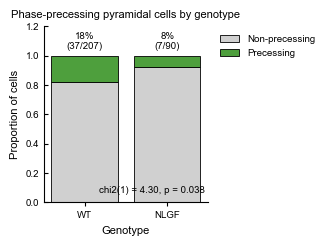

In [9]:
def _format_pvalue(pval):
    if pd.isna(pval):
        return "p = n/a"
    if pval < 0.001:
        return "p < 0.001"
    return f"p = {pval:.3f}"


def plot_phase_precession_proportions(contingency_table, title, save_stem):
    plot_counts = contingency_table[["Non-precessing", "Precessing"]].copy()
    plot_props = plot_counts.div(plot_counts.sum(axis=1), axis=0)

    chi2_stat, pval, dof, expected = chi2_contingency(plot_counts)

    fig, ax = plt.subplots(figsize=(3.35, 2.5))
    x = np.arange(len(plot_props.index))
    bottom = np.zeros(len(plot_props.index))

    colors = {
        "Non-precessing": "#D0D0D0",
        "Precessing": "#4E9F3D",
    }

    for label in ["Non-precessing", "Precessing"]:
        values = plot_props[label].to_numpy()
        ax.bar(
            x,
            values,
            bottom=bottom,
            color=colors[label],
            edgecolor="black",
            linewidth=0.6,
            label=label,
        )
        bottom += values

    for i, genotype in enumerate(plot_props.index):
        n_total = int(plot_counts.loc[genotype].sum())
        n_precessing = int(plot_counts.loc[genotype, "Precessing"])
        pct_precessing = plot_props.loc[genotype, "Precessing"] * 100

        ax.text(
            i,
            1.03,
            f"{pct_precessing:.0f}%\n({n_precessing}/{n_total})",
            ha="center",
            va="bottom",
            fontsize=7,
        )

    ax.text(
        0.98,
        0.04,
        f"chi2({dof}) = {chi2_stat:.2f}, {_format_pvalue(pval)}",
        transform=ax.transAxes,
        ha="right",
        va="bottom",
        fontsize=7,
    )

    ax.set_xticks(x)
    ax.set_xticklabels(plot_props.index)
    ax.set_ylim(0, 1.2)
    ax.set_ylabel("Proportion of cells")
    ax.set_xlabel("Genotype")
    ax.set_title(title)
    ax.legend(frameon=False, loc="upper left", bbox_to_anchor=(1.02, 1.0))
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    fig.tight_layout()

    pdf_path = phase_precession_OUTDIR / f"{save_stem}.pdf"
    png_path = phase_precession_OUTDIR / f"{save_stem}.png"
    fig.savefig(pdf_path)
    fig.savefig(png_path, dpi=300)

    print(f"Saved plot to: {pdf_path}")
    print(f"Saved plot to: {png_path}")
    plt.show()


plot_phase_precession_proportions(
    contingency,
    "Phase-precessing cells by genotype",
    "phase_precession_proportions_stacked",
)

plot_phase_precession_proportions(
    contingency_pyr,
    "Phase-precessing pyramidal cells by genotype",
    "phase_precession_proportions_pyramidal_stacked",
)

# Analysis of PAC comodulogram metrics 


## Mann-Whitney analysis 

In [32]:
"""
Analysis of PAC comodulogram metrics (modulation index, preferred phase) would follow a similar structure:
It will save:
lfp_stats_outputs/
  mannwhitney_results.csv
  <metric>_<task>_violin.pdf
  <metric>_<genotype>_paired_tasks.pdf).
"""

import os
import warnings
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

from scipy.stats import mannwhitneyu
import statsmodels.formula.api as smf

# ─── Journal / Illustrator global styles ──────────────────────────────────────
mpl.rcParams.update({
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "font.family": "Arial",
    "axes.grid": False,
    "font.size": 8,
    "axes.labelsize": 8,
    "axes.titlesize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 7,
    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "ytick.left": True,
    "ytick.direction": "in",
    "savefig.transparent": True,
    "savefig.bbox": "tight",
})

GENO_ORDER  = ["WT", "NLGF"]
GENO_COLORS = {"NLGF": "#E07B54", "WT": "#5B8DB8"}

def _pstars(p):
    if pd.isna(p): return ""
    if p < 0.001:  return "***"
    if p < 0.01:   return "**"
    if p < 0.05:   return "*"
    return "ns"


# ─── Load data ────────────────────────────────────────────────────────────────
basepath = Path('/Users/loukia/Library/CloudStorage/Dropbox-UCL/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/Analysis/LFP_analysis')
LFP_CSV_PATH = basepath / 'concatenated_lfp_stats.csv'
OUTPUT_DIR = LFP_CSV_PATH.parent.parent / 'LFP_analysis'
os.makedirs(OUTPUT_DIR, exist_ok=True)

df = pd.read_csv(LFP_CSV_PATH)

# Clean names / categorical order
df["Phenotype"] = pd.Categorical(df["Phenotype"], categories=GENO_ORDER, ordered=True)
df["environment"] = df["environment"].astype(str)
df["mouse_name"] = df["mouse_name"].astype(str)
df["Experimenter"] = df["Experimenter"].astype(str)

# ─── Metrics to analyse ───────────────────────────────────────────────────────
metrics = {
    "max_theta_freq": "Theta peak frequency (Hz)",
    "comodulogram_PAC_slow_gamma": "Theta–slow gamma PAC",
    "comodulogram_PAC_fast_gamma": "Theta–fast gamma PAC",
    "n_oscillatory_epochs_slow_gamm": "Slow gamma event count",
    "n_oscillatory_epochs_fast_gamma": "Fast gamma event count",
    "theta_running_slope": "Theta–running slope",
    "theta_running_intercept": "Theta–running intercept",
    "theta_running_rvalue": "Theta–running r",
}

metrics = {k: v for k, v in metrics.items() if k in df.columns}


# ─── Mann–Whitney tests: WT vs NLGF within each task ───────────────────────────
mw_results = []

for metric in metrics:
    for env in sorted(df["environment"].dropna().unique()):
        sub = df.loc[df["environment"] == env, ["Phenotype", metric]].dropna()

        wt = sub.loc[sub["Phenotype"] == "WT", metric].values
        ko = sub.loc[sub["Phenotype"] == "NLGF", metric].values

        if len(wt) > 0 and len(ko) > 0:
            stat, p = mannwhitneyu(wt, ko, alternative="two-sided")
        else:
            stat, p = np.nan, np.nan

        mw_results.append({
            "metric": metric,
            "environment": env,
            "n_WT": len(wt),
            "n_NLGF": len(ko),
            "WT_median": np.nanmedian(wt) if len(wt) else np.nan,
            "NLGF_median": np.nanmedian(ko) if len(ko) else np.nan,
            "mannwhitney_U": stat,
            "pvalue": p,
            "stars": _pstars(p),
        })

mw_results = pd.DataFrame(mw_results)
mw_results.to_csv(os.path.join(OUTPUT_DIR, "mannwhitney_results.csv"), index=False)


# ─── Plotting helper ──────────────────────────────────────────────────────────
def plot_metric_violin(data, metric, ylabel, save=True):
    envs = sorted(data["environment"].dropna().unique())

    for env in envs:
        sub = data.loc[data["environment"] == env].copy()
        sub = sub[["Phenotype", "mouse_name", metric]].dropna()

        genos = [g for g in GENO_ORDER if g in sub["Phenotype"].astype(str).values]

        if len(genos) < 2:
            continue

        vals = {
            g: sub.loc[sub["Phenotype"].astype(str) == g, metric].values
            for g in genos
        }

        fig, ax = plt.subplots(figsize=(1.65, 2.6))

        # ── Violin Mann–Whitney results ────────────────────────────────────────────────────
        if all(len(vals[g]) >= 3 for g in genos):
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                parts = ax.violinplot(
                    [vals[g] for g in genos],
                    positions=list(range(len(genos))),
                    showmedians=False,
                    showextrema=False,
                    widths=0.8,
                )

            for i_v, pc in enumerate(parts["bodies"]):
                pc.set_facecolor(GENO_COLORS.get(genos[i_v], "#aaaaaa"))
                pc.set_alpha(0.45)
                pc.set_edgecolor("none")

        # ── Median and IQR ───────────────────────────────────────────────────
        for xi, g in enumerate(genos):
            if len(vals[g]) == 0:
                continue

            q1  = np.nanpercentile(vals[g], 25)
            med = np.nanmedian(vals[g])
            q3  = np.nanpercentile(vals[g], 75)

            ax.hlines([q1, q3], xi - 0.16, xi + 0.16,
                      colors="black", linewidth=0.8, zorder=7)
            ax.hlines(med, xi - 0.24, xi + 0.24,
                      colors="black", linewidth=1.6, zorder=8)

        # ── Individual points ────────────────────────────────────────────────
        rng = np.random.default_rng(10)

        for xi, g in enumerate(genos):
            y = vals[g]
            jitter = rng.normal(0, 0.045, size=len(y))
            ax.scatter(
                np.full(len(y), xi) + jitter,
                y,
                s=14,
                color=GENO_COLORS.get(g, "#aaaaaa"),
                edgecolor="black",
                linewidth=0.35,
                alpha=0.9,
                zorder=10,
            )

        # ── Mann–Whitney annotation ──────────────────────────────────────────
        p_row = mw_results[
            (mw_results["metric"] == metric) &
            (mw_results["environment"] == env)
        ]

        if len(p_row):
            p = p_row["pvalue"].iloc[0]
            stars = _pstars(p)

            ymax = np.nanmax(sub[metric].values)
            ymin = np.nanmin(sub[metric].values)
            yrng = ymax - ymin if ymax > ymin else ymax * 0.1

            y = ymax + 0.12 * yrng
            h = 0.04 * yrng

            ax.plot([0, 0, 1, 1], [y, y+h, y+h, y],
                    color="black", linewidth=0.8, clip_on=False)
            ax.text(0.5, y+h, stars, ha="center", va="bottom", fontsize=8)

        # ── Axes ─────────────────────────────────────────────────────────────
        ax.set_xticks(range(len(genos)))
        ax.set_xticklabels(genos)
        ax.set_ylabel(ylabel)
        ax.set_title(env)

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        fig.tight_layout()

        if save:
            clean_metric = metric.replace("/", "_")
            clean_env = env.replace(" ", "_")
            fig.savefig(
                os.path.join(OUTPUT_DIR, f"{clean_metric}_{clean_env}_violin.pdf")
            )

        plt.close(fig)

# ─── Make all violin plots ────────────────────────────────────────────────────
for metric, ylabel in metrics.items():
    plot_metric_violin(df, metric, ylabel)
    plt.show()
    plt.close()


print("Done.")
print(f"Saved results and figures to: {OUTPUT_DIR}")

Done.
Saved results and figures to: /Users/loukia/Library/CloudStorage/Dropbox-UCL/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/Analysis/LFP_analysis


In [ ]:
"""
Analysis and figures for PAC slow and fast gamma usling mixed linear model with interaction terms:
- genotype effect
- gamma band effect
- genotype × gamma interaction
- environment interactions
"""


# ─── Long-format PAC dataframe ────────────────────────────────────────────────
pac_fast = df[[
    "mouse_name",
    "Phenotype",
    "environment",
    "Age_weeks",
    "Experimenter",
    "comodulogram_PAC_fast_gamma"
]].copy()

pac_fast["gamma_band"] = "fast"
pac_fast = pac_fast.rename(
    columns={"comodulogram_PAC_fast_gamma": "PAC"}
)

pac_slow = df[[
    "mouse_name",
    "Phenotype",
    "environment",
    "Age_weeks",
    "Experimenter",
    "comodulogram_PAC_slow_gamma"
]].copy()

pac_slow["gamma_band"] = "slow"
pac_slow = pac_slow.rename(
    columns={"comodulogram_PAC_slow_gamma": "PAC"}
)

pac_df = pd.concat([pac_fast, pac_slow], ignore_index=True)

pac_df = pac_df.dropna(subset=["PAC"])      


# ─── PAC interaction mixed model ──────────────────────────────────────────────
#
# Tests:
# - genotype effect
# - gamma band effect
# - genotype × gamma interaction
# - environment interactions

pac_model = smf.mixedlm(
    "PAC ~ Phenotype * gamma_band * environment",
    data=pac_df,
    groups=pac_df["mouse_name"] # random intercept for each mouse equivalent to (1 | mouse_name) 
)

pac_fit = pac_model.fit(reml=False, method="lbfgs")

print(pac_fit.summary())

with open(os.path.join(OUTPUT_DIR, "PAC_gamma_interaction_model.txt"), "w") as f:
    f.write(str(pac_fit.summary()))

                                  Mixed Linear Model Regression Results
Model:                             MixedLM                  Dependent Variable:                  PAC     
No. Observations:                  68                       Method:                              ML      
No. Groups:                        17                       Scale:                               0.0000  
Min. group size:                   4                        Log-Likelihood:                      443.1688
Max. group size:                   4                        Converged:                           Yes     
Mean group size:                   4.0                                                                   
---------------------------------------------------------------------------------------------------------
                                                               Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------------------------------

Saved plot to: /Users/loukia/Library/CloudStorage/Dropbox-UCL/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/Analysis/LFP_analysis_mixed_model_outputs/PAC_gamma_interaction_violin.pdf


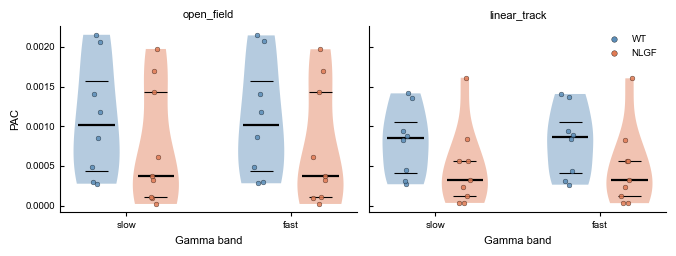

In [52]:
# ─── PAC interaction violin plot ──────────────────────────────────────────────

env_order = ["open_field", "linear_track"]
gamma_order = ["slow", "fast"]

fig, axes = plt.subplots(
    1,
    len(env_order),
    figsize=(6.8, 2.6),
    sharey=True,
)

if len(env_order) == 1:
    axes = [axes]

rng = np.random.default_rng(10)

for ax, env in zip(axes, env_order):

    sub_env = pac_df[pac_df["environment"] == env].copy()

    group_centers = np.arange(len(gamma_order))
    dodge = {"WT": -0.18, "NLGF": 0.18}
    width = 0.28

    for gi, gamma in enumerate(gamma_order):

        sub_gamma = sub_env[sub_env["gamma_band"] == gamma]

        for geno in GENO_ORDER:

            vals = sub_gamma.loc[
                sub_gamma["Phenotype"].astype(str) == geno,
                "PAC"
            ].dropna().values

            if len(vals) == 0:
                continue

            xpos = group_centers[gi] + dodge[geno]

            # ── Violin ───────────────────────────────────────────────────────
            if len(vals) >= 3:
                with warnings.catch_warnings():
                    warnings.simplefilter("ignore")
                    parts = ax.violinplot(
                        vals,
                        positions=[xpos],
                        showmedians=False,
                        showextrema=False,
                        widths=width,
                    )

                for pc in parts["bodies"]:
                    pc.set_facecolor(GENO_COLORS.get(geno, "#aaaaaa"))
                    pc.set_alpha(0.45)
                    pc.set_edgecolor("none")

            # ── Median and IQR ───────────────────────────────────────────────
            q1 = np.nanpercentile(vals, 25)
            med = np.nanmedian(vals)
            q3 = np.nanpercentile(vals, 75)

            ax.hlines(
                [q1, q3],
                xpos - 0.07,
                xpos + 0.07,
                colors="black",
                linewidth=0.8,
                zorder=7,
            )

            ax.hlines(
                med,
                xpos - 0.11,
                xpos + 0.11,
                colors="black",
                linewidth=1.6,
                zorder=8,
            )

            # ── Individual points ────────────────────────────────────────────
            jitter = rng.normal(0, 0.025, size=len(vals))

            ax.scatter(
                np.full(len(vals), xpos) + jitter,
                vals,
                s=12,
                color=GENO_COLORS.get(geno, "#aaaaaa"),
                edgecolor="black",
                linewidth=0.25,
                alpha=0.85,
                zorder=10,
            )

    ax.set_xticks(group_centers)
    ax.set_xticklabels(gamma_order)
    ax.set_xlabel("Gamma band")
    ax.set_title(env)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

axes[0].set_ylabel("PAC")

legend_handles = [
    Line2D(
        [0], [0],
        marker="o",
        linestyle="none",
        markerfacecolor=GENO_COLORS[g],
        markeredgecolor="black",
        markeredgewidth=0.25,
        markersize=4,
        label=g,
    )
    for g in GENO_ORDER
]

axes[-1].legend(
    handles=legend_handles,
    frameon=False,
    loc="upper right",
)

fig.tight_layout()

pdf_path = os.path.join(OUTPUT_DIR, "PAC_gamma_interaction_violin.pdf")
png_path = os.path.join(OUTPUT_DIR, "PAC_gamma_interaction_violin.png")

fig.savefig(pdf_path)

print(f"Saved plot to: {pdf_path}")

plt.show()

## Mixed models analysis 

In [37]:
"""
Analysis of PAC comodulogram metrics (modulation index, preferred phase) would follow a similar structure:
It will save:
lfp_stats_outputs/
  mannwhitney_results.csv
  mixed_model_results.csv
  mixed_model_<metric>.txt
  <metric>_<task>_violin.pdf
  <metric>_<genotype>_paired_tasks.pdf).
"""

import os
import warnings
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

from scipy.stats import mannwhitneyu
import statsmodels.formula.api as smf

# ─── Journal / Illustrator global styles ──────────────────────────────────────
mpl.rcParams.update({
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "font.family": "Arial",
    "axes.grid": False,
    "font.size": 8,
    "axes.labelsize": 8,
    "axes.titlesize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 7,
    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "ytick.left": True,
    "ytick.direction": "in",
    "savefig.transparent": True,
    "savefig.bbox": "tight",
})

GENO_ORDER  = ["WT", "NLGF"]
GENO_COLORS = {"NLGF": "#E07B54", "WT": "#5B8DB8"}

def _pstars(p):
    if pd.isna(p): return ""
    if p < 0.001:  return "***"
    if p < 0.01:   return "**"
    if p < 0.05:   return "*"
    return "ns"


# ─── Load data ────────────────────────────────────────────────────────────────
basepath = Path('/Users/loukia/Library/CloudStorage/Dropbox-UCL/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/Analysis/LFP_analysis')
LFP_CSV_PATH = basepath / 'concatenated_lfp_stats.csv'
OUTPUT_DIR = LFP_CSV_PATH.parent.parent / 'LFP_analysis'
os.makedirs(OUTPUT_DIR, exist_ok=True)

df = pd.read_csv(LFP_CSV_PATH)

# Clean names / categorical order
df["Phenotype"] = pd.Categorical(df["Phenotype"], categories=GENO_ORDER, ordered=True)
df["environment"] = df["environment"].astype(str)
df["mouse_name"] = df["mouse_name"].astype(str)
df["Experimenter"] = df["Experimenter"].astype(str)

# ─── Metrics to analyse ───────────────────────────────────────────────────────
metrics = {
    "max_theta_freq": "Theta peak frequency (Hz)",
    "comodulogram_PAC_slow_gamma": "Theta–slow gamma PAC",
    "comodulogram_PAC_fast_gamma": "Theta–fast gamma PAC",
    "n_oscillatory_epochs_slow_gamm": "Slow gamma event count",
    "n_oscillatory_epochs_fast_gamma": "Fast gamma event count",
    "theta_running_slope": "Theta–running slope",
    "theta_running_intercept": "Theta–running intercept",
    "theta_running_rvalue": "Theta–running r",
}

metrics = {k: v for k, v in metrics.items() if k in df.columns}



# ─── Mixed models ─────────────────────────────────────────────────────────────
#
# Model:
# metric ~ Phenotype * environment + (1 | mouse_name)
#
# Random intercept for mouse_name handles repeated measures
# across open field and linear track.

mixed_results = []

for metric in metrics:
    model_df = df[[
        metric,
        "Phenotype",
        "environment",
        "mouse_name"
    ]].dropna()

    if model_df["Phenotype"].nunique() < 2:
        continue

    if model_df["environment"].nunique() < 2:
        continue

    try:
        model = smf.mixedlm(
            f"{metric} ~ Phenotype * environment",
            data=model_df,
            groups=model_df["mouse_name"]
        )

        fit = model.fit(reml=False, method="lbfgs")

        for term, beta in fit.params.items():
            mixed_results.append({
                "metric": metric,
                "term": term,
                "beta": beta,
                "se": fit.bse.get(term, np.nan),
                "z": fit.tvalues.get(term, np.nan),
                "pvalue": fit.pvalues.get(term, np.nan),
                "stars": _pstars(fit.pvalues.get(term, np.nan)),
                "n": model_df.shape[0],
                "n_mice": model_df["mouse_name"].nunique(),
            })

        clean_metric = metric.replace("/", "_")

        with open(
            os.path.join(OUTPUT_DIR, f"mixed_model_{clean_metric}.txt"),
            "w"
        ) as f:
            f.write(str(fit.summary()))

    except Exception as e:
        mixed_results.append({
            "metric": metric,
            "term": "MODEL_FAILED",
            "beta": np.nan,
            "se": np.nan,
            "z": np.nan,
            "pvalue": np.nan,
            "stars": "",
            "n": model_df.shape[0],
            "n_mice": model_df["mouse_name"].nunique(),
            "error": str(e),
        })

mixed_results = pd.DataFrame(mixed_results)
mixed_results.to_csv(
    os.path.join(OUTPUT_DIR, "mixed_model_results.csv"),
    index=False
)

print("Done.")
print(f"Saved results to: {OUTPUT_DIR}")

Done.
Saved results to: /Users/loukia/Library/CloudStorage/Dropbox-UCL/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/Analysis/LFP_analysis


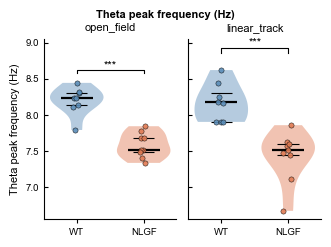

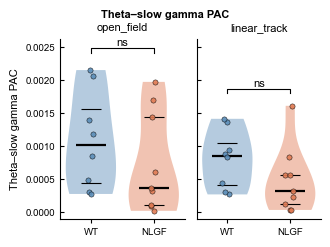

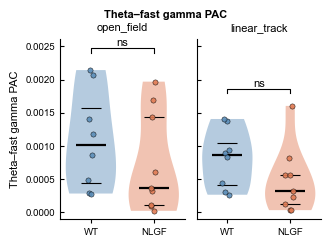

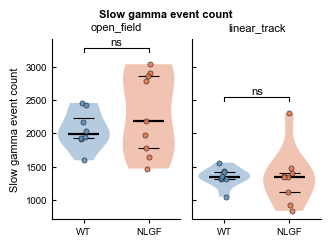

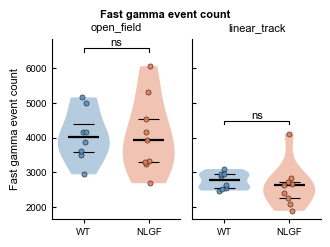

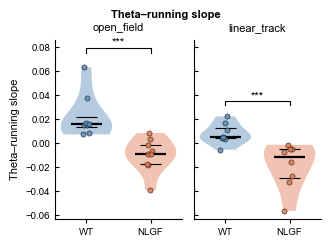

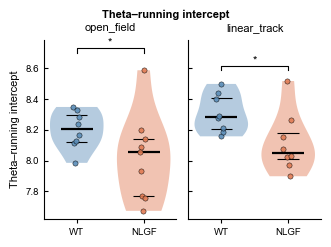

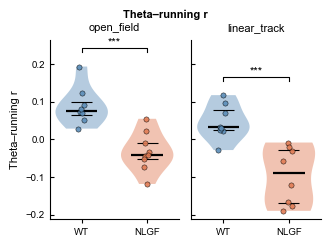

Done.
Saved results and figures to: /Users/loukia/Library/CloudStorage/Dropbox-UCL/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/Analysis/LFP_analysis_mixed_model_outputs


In [53]:
"""
LFP analysis:
- Mixed linear models:
    metric ~ Phenotype * environment + (1 | mouse_name)

- Violin plots:
    raw data shown as violins/points
    significance stars come from mixed-model genotype contrasts
    within each environment
"""

import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

from scipy.stats import norm
import statsmodels.formula.api as smf


# ─── Journal / Illustrator global styles ──────────────────────────────────────
mpl.rcParams.update({
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "font.family": "Arial",
    "axes.grid": False,
    "font.size": 8,
    "axes.labelsize": 8,
    "axes.titlesize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 7,
    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "ytick.left": True,
    "ytick.direction": "in",
    "savefig.transparent": True,
    "savefig.bbox": "tight",
})

GENO_ORDER  = ["WT", "NLGF"]
GENO_COLORS = {"NLGF": "#E07B54", "WT": "#5B8DB8"}


def _pstars(p):
    if pd.isna(p):
        return ""
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return "ns"


# ─── Load data ────────────────────────────────────────────────────────────────
basepath = Path(
    "/Users/loukia/Library/CloudStorage/Dropbox-UCL/"
    "Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/"
    "RobinData/Analysis/LFP_analysis"
)

LFP_CSV_PATH = basepath / "concatenated_lfp_stats.csv"
OUTPUT_DIR = LFP_CSV_PATH.parent.parent / "LFP_analysis_mixed_model_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

df = pd.read_csv(LFP_CSV_PATH)

df["Phenotype"] = pd.Categorical(
    df["Phenotype"],
    categories=GENO_ORDER,
    ordered=True
)

df["environment"] = df["environment"].astype(str)
df["mouse_name"] = df["mouse_name"].astype(str)

if "Experimenter" in df.columns:
    df["Experimenter"] = df["Experimenter"].astype(str)


# ─── Metrics to analyse ───────────────────────────────────────────────────────
metrics = {
    "max_theta_freq": "Theta peak frequency (Hz)",
    "comodulogram_PAC_slow_gamma": "Theta–slow gamma PAC",
    "comodulogram_PAC_fast_gamma": "Theta–fast gamma PAC",
    "n_oscillatory_epochs_slow_gamm": "Slow gamma event count",
    "n_oscillatory_epochs_fast_gamma": "Fast gamma event count",
    "theta_running_slope": "Theta–running slope",
    "theta_running_intercept": "Theta–running intercept",
    "theta_running_rvalue": "Theta–running r",
}

metrics = {k: v for k, v in metrics.items() if k in df.columns}


# ─── Mixed models + LMM genotype contrasts for plotting ───────────────────────
mixed_results = []
lmm_plot_pvals = []

for metric in metrics:

    model_df = df[[
        metric,
        "Phenotype",
        "environment",
        "mouse_name"
    ]].dropna()

    if model_df["Phenotype"].nunique() < 2:
        continue

    if model_df["environment"].nunique() < 2:
        continue

    try:
        model = smf.mixedlm(
            f"{metric} ~ Phenotype * environment",
            data=model_df,
            groups=model_df["mouse_name"]
        )

        fit = model.fit(reml=False, method="lbfgs")

        # Save full model terms
        for term, beta in fit.params.items():
            mixed_results.append({
                "metric": metric,
                "term": term,
                "beta": beta,
                "se": fit.bse.get(term, np.nan),
                "z": fit.tvalues.get(term, np.nan),
                "pvalue": fit.pvalues.get(term, np.nan),
                "stars": _pstars(fit.pvalues.get(term, np.nan)),
                "n": model_df.shape[0],
                "n_mice": model_df["mouse_name"].nunique(),
            })

        # Environment-specific NLGF vs WT contrasts from the LMM
        params = fit.params
        cov = fit.cov_params()

        for env in sorted(model_df["environment"].dropna().unique()):

            contrast = pd.Series(0.0, index=params.index)

            if "Phenotype[T.NLGF]" in contrast.index:
                contrast["Phenotype[T.NLGF]"] = 1.0

            interaction_term = f"Phenotype[T.NLGF]:environment[T.{env}]"

            if interaction_term in contrast.index:
                contrast[interaction_term] = 1.0

            beta = float(np.dot(contrast, params))
            se = float(np.sqrt(np.dot(contrast, np.dot(cov, contrast))))

            if se > 0:
                z = beta / se
                p = 2 * (1 - norm.cdf(abs(z)))
            else:
                z = np.nan
                p = np.nan

            lmm_plot_pvals.append({
                "metric": metric,
                "environment": env,
                "contrast": "NLGF_vs_WT",
                "beta": beta,
                "se": se,
                "z": z,
                "pvalue": p,
                "stars": _pstars(p),
                "n": model_df.loc[
                    model_df["environment"] == env
                ].shape[0],
                "n_mice": model_df.loc[
                    model_df["environment"] == env,
                    "mouse_name"
                ].nunique(),
            })

        clean_metric = metric.replace("/", "_")

        with open(
            os.path.join(OUTPUT_DIR, f"mixed_model_{clean_metric}.txt"),
            "w"
        ) as f:
            f.write(str(fit.summary()))

    except Exception as e:
        mixed_results.append({
            "metric": metric,
            "term": "MODEL_FAILED",
            "beta": np.nan,
            "se": np.nan,
            "z": np.nan,
            "pvalue": np.nan,
            "stars": "",
            "n": model_df.shape[0],
            "n_mice": model_df["mouse_name"].nunique(),
            "error": str(e),
        })


mixed_results = pd.DataFrame(mixed_results)
mixed_results.to_csv(
    os.path.join(OUTPUT_DIR, "mixed_model_results.csv"),
    index=False
)

lmm_plot_pvals = pd.DataFrame(lmm_plot_pvals)
lmm_plot_pvals.to_csv(
    os.path.join(OUTPUT_DIR, "mixed_model_plot_pvalues.csv"),
    index=False
)

# ─── Plotting helper: raw data violins + MLM genotype contrasts ──────────────
def plot_metric_violin_mlm(data, metric, ylabel, save=True):
    env_order = ["open_field", "linear_track"]
    envs = [env for env in env_order if env in data["environment"].dropna().unique()]

    if len(envs) == 0:
        return
    fig, axes = plt.subplots(
        1,
        len(envs),
        figsize=(3.35, 2.6),
        sharey=True
    )

    if len(envs) == 1:
        axes = [axes]

    rng = np.random.default_rng(10)

    for ax, env in zip(axes, envs):
        sub = data.loc[data["environment"] == env].copy()
        sub = sub[["Phenotype", "mouse_name", metric]].dropna()

        genos = [
            g for g in GENO_ORDER
            if g in sub["Phenotype"].astype(str).values
        ]

        if len(genos) < 2:
            ax.set_visible(False)
            continue

        vals = {
            g: sub.loc[sub["Phenotype"].astype(str) == g, metric].values
            for g in genos
        }

        if all(len(vals[g]) >= 3 for g in genos):
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                parts = ax.violinplot(
                    [vals[g] for g in genos],
                    positions=list(range(len(genos))),
                    showmedians=False,
                    showextrema=False,
                    widths=0.8,
                )

            for i_v, pc in enumerate(parts["bodies"]):
                pc.set_facecolor(GENO_COLORS.get(genos[i_v], "#aaaaaa"))
                pc.set_alpha(0.45)
                pc.set_edgecolor("none")

        for xi, g in enumerate(genos):
            if len(vals[g]) == 0:
                continue

            q1 = np.nanpercentile(vals[g], 25)
            med = np.nanmedian(vals[g])
            q3 = np.nanpercentile(vals[g], 75)

            ax.hlines(
                [q1, q3],
                xi - 0.16,
                xi + 0.16,
                colors="black",
                linewidth=0.8,
                zorder=7,
            )
            ax.hlines(
                med,
                xi - 0.24,
                xi + 0.24,
                colors="black",
                linewidth=1.6,
                zorder=8,
            )

            jitter = rng.normal(0, 0.045, size=len(vals[g]))
            ax.scatter(
                np.full(len(vals[g]), xi) + jitter,
                vals[g],
                s=14,
                color=GENO_COLORS.get(g, "#aaaaaa"),
                edgecolor="black",
                linewidth=0.35,
                alpha=0.9,
                zorder=10,
            )

        # MLM annotation from the mixed-model cell above
        p_row = lmm_plot_pvals[
            (lmm_plot_pvals["metric"] == metric) &
            (lmm_plot_pvals["environment"] == env) &
            (lmm_plot_pvals["contrast"] == "NLGF_vs_WT")
        ]

        if len(p_row):
            p = p_row["pvalue"].iloc[0]
            stars = _pstars(p)

            ymax = np.nanmax(sub[metric].values)
            ymin = np.nanmin(sub[metric].values)
            yrng = ymax - ymin if ymax > ymin else max(abs(ymax) * 0.1, 1.0)

            y = ymax + 0.12 * yrng
            h = 0.04 * yrng

            ax.plot(
                [0, 0, 1, 1],
                [y, y + h, y + h, y],
                color="black",
                linewidth=0.8,
                clip_on=False,
            )
            ax.text(
                0.5,
                y + h,
                stars,
                ha="center",
                va="bottom",
                fontsize=8,
            )

        ax.set_xticks(range(len(genos)))
        ax.set_xticklabels(genos)
        ax.set_title(env)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    axes[0].set_ylabel(ylabel)
    fig.suptitle(ylabel, y=0.92, fontsize=8, fontweight="bold")
    fig.tight_layout()

    if save:
        clean_metric = metric.replace("/", "_")
        fig.savefig(os.path.join(OUTPUT_DIR, f"{clean_metric}_violin_LMM.pdf"))

    plt.show()
    plt.close(fig)


# ─── Make all violin plots ────────────────────────────────────────────────────
for metric, ylabel in metrics.items():
    plot_metric_violin_mlm(df, metric, ylabel)

print("Done.")
print(f"Saved results and figures to: {OUTPUT_DIR}")

In [40]:
# ── Compare MLM vs Mann-Whitney U: concordance of significance ───────────────
from IPython.display import display, HTML

ALPHA = 0.05

# Mixed linear model: environment-specific NLGF vs WT contrasts
mlm = lmm_plot_pvals[
    lmm_plot_pvals["contrast"] == "NLGF_vs_WT"
][[
    "metric",
    "environment",
    "beta",
    "se",
    "z",
    "pvalue",
    "n",
    "n_mice",
]].copy()

mlm = mlm.rename(columns={
    "beta": "mlm_beta",
    "se": "mlm_se",
    "z": "mlm_z",
    "pvalue": "mlm_p",
    "n": "mlm_n",
    "n_mice": "mlm_n_mice",
})
mlm["mlm_sig"] = mlm["mlm_p"] < ALPHA

# Mann-Whitney
mwu = mw_results[[
    "metric",
    "environment",
    "n_WT",
    "n_NLGF",
    "WT_median",
    "NLGF_median",
    "mannwhitney_U",
    "pvalue",
]].copy()

mwu = mwu.rename(columns={
    "pvalue": "mwu_p",
})
mwu["mwu_sig"] = mwu["mwu_p"] < ALPHA

# Merge on metric × environment
comp = pd.merge(
    mlm,
    mwu,
    on=["metric", "environment"],
    how="outer",
    indicator=True,
)

# Classification
def classify(row):
    g = bool(row.get("mlm_sig")) if pd.notna(row.get("mlm_sig")) else False
    m = bool(row.get("mwu_sig")) if pd.notna(row.get("mwu_sig")) else False

    if g and m:
        return "both"
    if g:
        return "MLM only"
    if m:
        return "MWU only"
    return "neither"

comp["concordance"] = comp.apply(classify, axis=1)

# p-value formatter
def _fmt_p(p):
    if pd.isna(p):
        return "—"
    if p < 0.001:
        return f"{p:.4f} ***"
    if p < 0.01:
        return f"{p:.4f} **"
    if p < 0.05:
        return f"{p:.4f} *"
    return f"{p:.4f}"

# Force environment display order
env_order = ["open_field", "linear_track"]
comp["environment"] = pd.Categorical(
    comp["environment"],
    categories=env_order,
    ordered=True
)

# ── Display: summary by concordance ───────────────────────────────────────────
display(HTML("<h3>Mixed Linear Model vs Mann-Whitney U — concordance of significance</h3>"))

for label in ["both", "MLM only", "MWU only", "neither"]:
    grp = comp[comp["concordance"] == label].copy()
    if grp.empty:
        continue

    display(HTML(f"<h4>{label} ({len(grp)} comparisons)</h4>"))

    show = grp[[
        "metric",
        "environment",
        "mlm_p",
        "mlm_beta",
        "mlm_se",
        "mlm_z",
        "mwu_p",
        "mannwhitney_U",
        "WT_median",
        "NLGF_median",
        "n_WT",
        "n_NLGF",
    ]].sort_values(["environment", "metric"])

    def _colour_row(row):
        g = row.get("mlm_p", np.nan)
        m = row.get("mwu_p", np.nan)

        g_sig = pd.notna(g) and g < ALPHA
        m_sig = pd.notna(m) and m < ALPHA

        if g_sig and m_sig:
            bg = "#c8e6c9"
        elif g_sig or m_sig:
            bg = "#fff9c4"
        else:
            bg = ""

        return [f"background-color:{bg}" if bg else "" for _ in row]

    display(
        show.style
            .apply(_colour_row, axis=1)
            .format({
                "mlm_p": "{:.4f}",
                "mlm_beta": "{:.4f}",
                "mlm_se": "{:.4f}",
                "mlm_z": "{:.3f}",
                "mwu_p": "{:.4f}",
                "mannwhitney_U": "{:.2f}",
                "WT_median": "{:.4f}",
                "NLGF_median": "{:.4f}",
            })
            .set_properties(**{"font-size": "11px"})
    )

# ── Quick count summary ───────────────────────────────────────────────────────
print("\nConcordance counts")
print(comp["concordance"].value_counts().to_string())

# Optional compact summary by environment
print("\nConcordance by environment")
print(pd.crosstab(comp["environment"], comp["concordance"]).to_string())

# ── Save ──────────────────────────────────────────────────────────────────────
comp_path = os.path.join(OUTPUT_DIR, "mlm_vs_mwu_concordance.csv")
comp[[
    "metric",
    "environment",
    "mlm_p",
    "mlm_beta",
    "mlm_se",
    "mlm_z",
    "mlm_n",
    "mlm_n_mice",
    "mwu_p",
    "mannwhitney_U",
    "n_WT",
    "n_NLGF",
    "WT_median",
    "NLGF_median",
    "concordance",
]].to_csv(comp_path, index=False)

print(f"\nSaved: {comp_path}")

,metric,environment,mlm_p,mlm_beta,mlm_se,mlm_z,mwu_p,mannwhitney_U,WT_median,NLGF_median,n_WT,n_NLGF
5,max_theta_freq,open_field,0.0000,-0.6153,0.1162,-5.295,0.0002,71.00,8.2328,7.5164,8,9
13,theta_running_rvalue,open_field,0.0000,-0.1213,0.0258,-4.695,0.0003,70.00,0.0763,-0.0424,8,9
15,theta_running_slope,open_field,0.0000,-0.0324,0.0071,-4.567,0.0002,71.00,0.0160,-0.0088,8,9
4,max_theta_freq,linear_track,0.0000,-0.7420,0.1162,-6.384,0.0001,72.00,8.1716,7.5102,8,9
10,theta_running_intercept,linear_track,0.0356,-0.1889,0.0899,-2.102,0.0281,53.00,8.2854,8.0512,8,8
12,theta_running_rvalue,linear_track,0.0000,-0.1444,0.0265,-5.449,0.0006,62.00,0.0322,-0.0897,8,8
14,theta_running_slope,linear_track,0.0002,-0.0271,0.0072,-3.736,0.0011,61.00,0.0052,-0.0114,8,8


,metric,environment,mlm_p,mlm_beta,mlm_se,mlm_z,mwu_p,mannwhitney_U,WT_median,NLGF_median,n_WT,n_NLGF
11,theta_running_intercept,open_field,0.0479,-0.1757,0.0888,-1.978,0.0745,55.00,8.2023,8.0526,8,9


,metric,environment,mlm_p,mlm_beta,mlm_se,mlm_z,mwu_p,mannwhitney_U,WT_median,NLGF_median,n_WT,n_NLGF
1,comodulogram_PAC_fast_gamma,open_field,0.2185,-0.0004,0.0003,-1.231,0.3213,47.00,0.0010,0.0004,8,9
3,comodulogram_PAC_slow_gamma,open_field,0.2196,-0.0004,0.0003,-1.228,0.3213,47.00,0.0010,0.0004,8,9
7,n_oscillatory_epochs_fast_gamma,open_field,0.9765,10.1667,345.4417,0.029,0.8884,38.00,4016.5000,3918.0000,8,9
9,n_oscillatory_epochs_slow_gamm,open_field,0.2105,236.1806,188.6008,1.252,0.4807,28.00,1987.0000,2183.0000,8,9
0,comodulogram_PAC_fast_gamma,linear_track,0.2485,-0.0003,0.0003,-1.154,0.1139,53.00,0.0009,0.0003,8,9
2,comodulogram_PAC_slow_gamma,linear_track,0.2533,-0.0003,0.0003,-1.142,0.1388,52.00,0.0009,0.0003,8,9
6,n_oscillatory_epochs_fast_gamma,linear_track,0.6927,-136.5000,345.4417,-0.395,0.2359,49.00,2761.0000,2627.0000,8,9
8,n_oscillatory_epochs_slow_gamm,linear_track,0.9926,1.7500,188.6008,0.009,0.8884,38.00,1342.0000,1345.0000,8,9



Concordance counts
concordance
neither     8
both        7
MLM only    1

Concordance by environment
concordance   MLM only  both  neither
environment                          
open_field           1     3        4
linear_track         0     4        4

Saved: /Users/loukia/Library/CloudStorage/Dropbox-UCL/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/Analysis/LFP_analysis_mixed_model_outputs/mlm_vs_mwu_concordance.csv
